# Analysis of the Relationship Between Product Categories and Sales Effectiveness (Inner)

## Member: Phuong

### Bàn luận:
Dựa trên phần EDA, ta có thể thấy có 5 root mỗi root chứa nhiều middle, mỗi middle chứa nhiều leaf
Vì vậy có rất nhiều thứ cần phải phân tích trong một danh mục.
Để đảm bảo insight được khách quan và thực sự cung cấp thông tin hữu ích cho người đọc. Em sẽ tiếp cận bằng một mục tiêu phân tích bao quát nhất

### Analysis Objectives:
1. **Question 1**: Với từng root danh mục, danh mục con trực tiếp nào đang phát triển mạnh nhất (doanh thu, số danh mục con, tổng sản phẩm)?
2. **Question 2**: Khám phá chuyên sâu những danh mục phát triển mạnh nhất đó xem yếu tố nào chính là yếu tố ảnh hưởng lớn nhất (Dùng linear để predict doanh thu xem cái nào có trọng số cao nhất)?
attributes: trong bảng product
target: price * sold_count


!!! - Chấp nhận rằng linear chỉ cho bạn insight tuyến tính, không phải là “chân lý” nhân quả.

In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, FixedLocator
from IPython.display import display

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)


# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [ ]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (496, 4)
Products: (55883, 14)
Reviews: (158126, 9)


## 2. Category Exploration
- Khám phá các root category (trỏng có bao nhiêu nhánh)
- EDA cơ bản về dữ liệu từng category (doanh thu tổng, chart danh thu cho từng category)
- ...

In [46]:
sns.set_theme(style="whitegrid")
main_cmap = sns.color_palette("mako", as_cmap=True)

In [47]:
# parent_dict = dict(zip(df_category['category_name'], df_category['parent_category'])) 
# root_categories = [
#     "diengiadung", 
#     "dienthoai_maytinhbang", 
#     "dientu_dienlanh", 
#     "laptop_mayvitinh_linhkien", 
#     "thietbiso_phukienso"
# ]

# for root in root_categories:
#     df_category.loc[df_category['category_name'] == root, 'root_category'] = root
# cat_to_root_dict = dict(zip(df_category['category_id'], df_category['root_category']))
# df_product_eda = df_product.copy()
# df_product_eda['category_id'] = df_product_eda['category_id'].astype(str)
# df_product_eda['root_category'] = df_product_eda['category_id'].map(cat_to_root_dict)
# df_product_eda['price'] = pd.to_numeric(df_product_eda['price'], errors='coerce').fillna(0)
# df_product_eda['sold_count'] = pd.to_numeric(df_product_eda['sold_count'], errors='coerce').fillna(0)
# df_product_eda['revenue'] = df_product_eda['price'] * df_product_eda['sold_count']

# # --- CẤU HÌNH STYLE ĐỒNG NHẤT ---
# plt.rcParams['font.family'] = 'sans-serif'
# sns.set_theme(style="white", palette="crest") # Sử dụng crest xuyên suốt
# MAIN_COLOR = "#234d51" # Màu chủ đạo lấy từ palette crest

# fig = plt.figure(figsize=(18, 14))
# # Tăng chiều cao cho hàng 1 để Donut chart có không gian
# gs = fig.add_gridspec(
#     2, 2,
#     height_ratios=[1, 1.2],  # boxplot lớn hơn
#     width_ratios=[1, 1],     # cân 2 bên
#     hspace=0.25,
#     wspace=0.15              # thêm khoảng cách ngang
# )

# def format_money(x, pos):
#     if x >= 1_000_000_000: return f'{x / 1_000_000_000:,.1f}B'
#     if x >= 1_000_000: return f'{x / 1_000_000:,.0f}M'
#     return f'{x:,.0f}'

# # --- AX1: BAR CHART (Đồng bộ màu) ---
# ax1 = fig.add_subplot(gs[0, 0])
# sub_cat_count = df_category[df_category['parent_category'] != ''].groupby('root_category')['category_id'].count().sort_values(ascending=False)
    
# sns.barplot(x=sub_cat_count.values, y=sub_cat_count.index, palette="mako", ax=ax1)
# ax1.set_title('1. CẤU TRỤC DANH MỤC\n(Số lượng danh mục con)', loc='left', fontweight='bold', pad=15)
# ax1.set_xlabel('Số lượng danh mục nhánh')
# ax1.set_ylabel('')

# for i, v in enumerate(sub_cat_count.values):
#     ax1.text(v + 0.5, i, f' {int(v)}', va='center', fontweight='bold', color=MAIN_COLOR)
# sns.despine(ax=ax1, left=True, bottom=True)

# # --- AX2: DONUT CHART (Phóng to & Cân đối) ---
# ax2 = fig.add_subplot(gs[0, 1])
# revenue_by_root = df_product_eda.groupby('root_category')['revenue'].sum().sort_values(ascending=False)
# revenue_by_root = revenue_by_root[revenue_by_root > 0]

# # Tăng size bằng cách điều chỉnh radius
# wedges, texts, autotexts = ax2.pie(
#     revenue_by_root.values, 
#     autopct='%1.1f%%',
#     startangle=140, 
#     pctdistance=0.75,
#     radius=1.1, # Phóng to donut
#     colors=sns.color_palette("viridis", len(revenue_by_root)),
#     wedgeprops={'width': 0.45, 'edgecolor': 'w', 'linewidth': 2}
# )

# ax2.legend(
#     wedges, revenue_by_root.index,
#     title="Danh mục",
#     loc="center left",
#     bbox_to_anchor=(1.05, 0.5),  # đặt bên phải
#     frameon=False
# )

# plt.setp(autotexts, size=10, weight="bold", color="white")
# ax2.set_title(
#     '2. CƠ CẤU DOANH THU\n(% Đóng góp)',
#     loc='left',
#     fontweight='bold',
#     pad=15  # giảm pad cho cân
# )
# # --- AX3: BOXPLOT (Fix Median Log Scale) ---
# ax3 = fig.add_subplot(gs[1, :])
# top5_roots_by_items = df_product_eda['root_category'].value_counts().head(5).index
# df_boxplot = df_product_eda[(df_product_eda['root_category'].isin(top5_roots_by_items)) & (df_product_eda['price'] > 0)]

# sns.boxplot(
#     data=df_boxplot, x='price', y='root_category',
#     palette="crest", showfliers=False, ax=ax3, width=0.5
# )

# ax3.set_xscale('log')
# major_ticks = [1e3, 5e3, 1e4, 5e4, 1e5, 5e5, 1e6, 5e6, 1e7, 5e7, 1e8]
# ax3.set_xticks(major_ticks)
# ax3.xaxis.set_major_formatter(FuncFormatter(format_money))

# ax3.margins(y=0.2)
# ax3.set_title(
#     '3. BIẾN ĐỘNG GIÁ SẢN PHẨM \n(Thang Logarit)',
#     loc='left',
#     fontweight='bold',
#     pad=20
# )

# ax3.set_xlabel('Giá bán (VND) - Trục hoành thang Log')
# ax3.set_ylabel('')
# sns.despine(ax=ax3)

# # --- TỔNG THỂ ---
# total_rev = df_product_eda['revenue'].sum()
# fig.suptitle(
#     f"DASHBOARD TỔNG QUAN DANH MỤC\nDoanh thu: {format_money(total_rev, None)} | Sản phẩm: {len(df_product_eda):,}",
#     fontsize=18,
#     fontweight='bold',
#     y=1.05   
# )
# for ax in [ax1, ax2, ax3]:
#     ax.title.set_ha('left')
#     ax.title.set_position((0, 1.02))
# fig = plt.figure(figsize=(18, 14), constrained_layout=True)
# plt.show()

## 3. Question 1: 

Chốt: doanh thu = discounted_price (nếu có) * sold (nếu không có discounted_price thì dùng price)
Note: nói trong câu 1 là mình chấp nhận tính tương đối của doanh thu

In [48]:
df_q1_category = df_category.copy()
df_q1_product = df_product.copy()

In [49]:
df_q1_product["revenue"] = df_q1_product["sold_count"] * df_q1_product["price"]

root_ids = set(df_category[df_category["parent_category"].isna()]["category_id"])

# mapping
parent_map = dict(zip(df_q1_category["category_id"], df_q1_category["parent_category"]))
name_to_id = dict(zip(df_q1_category["category_name"], df_q1_category["category_id"]))
id_to_name = dict(zip(df_q1_category["category_id"], df_q1_category["category_name"]))

cat_to_root = {}

for cat_id in df_q1_category["category_id"]:
    current = cat_id
    
    while pd.notna(parent_map[current]):
        parent_name = parent_map[current]
        current = name_to_id[parent_name]
    
    cat_to_root[cat_id] = current

df_q1_product["root_category_id"] = df_q1_product["category_id"].map(cat_to_root)

cat_name_map = df_category.set_index("category_id")["category_name"]

df_q1_product["category_name"] = df_q1_product["category_id"].map(cat_name_map)
df_q1_product["root_category_name"] = df_q1_product["root_category_id"].map(cat_name_map)

df_group = (
    df_q1_product
    .groupby(["root_category_name", "category_name"])["revenue"]
    .sum()
    .reset_index()
)

df_group["rank"] = df_group.groupby("root_category_name")["revenue"] \
                          .rank(method="first", ascending=False)

top5_each_root = df_group[df_group["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

df_group["pct_in_root"] = df_group["revenue"] / df_group.groupby("root_category_name")["revenue"].transform("sum")



In [50]:
# =========================
# TOP 5 TOÀN BỘ
# =========================
top5_all = (
    df_group
    .groupby("category_name")["revenue"]
    .sum()
    .reset_index()
    .sort_values(by="revenue", ascending=False)
    .head(5)
)

# average revenue (toàn bộ category)
avg_all = df_group.groupby("category_name")["revenue"].sum().mean()

# =========================
# TOP 5 MỖI ROOT
# =========================
top5_each_root = df_group[df_group["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

# average theo từng root
avg_each_root = (
    df_group
    .groupby("root_category_name")["revenue"]
    .mean()
    .reset_index(name="avg_revenue")
)


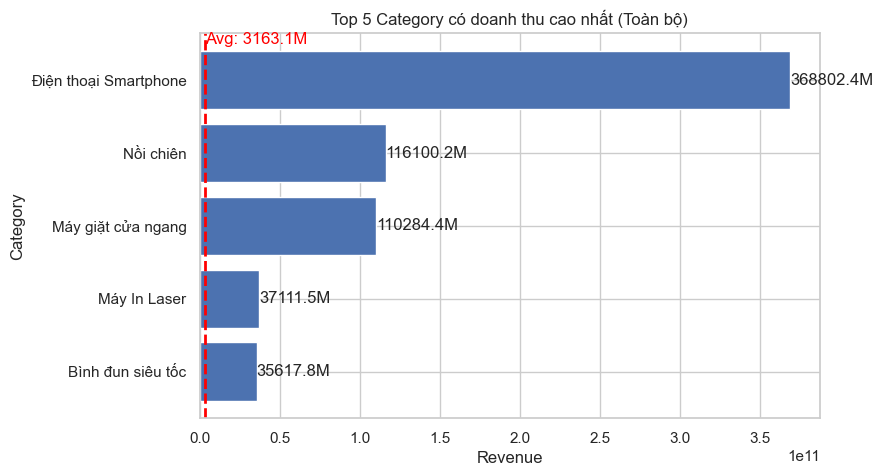

In [51]:
plt.figure(figsize=(8,5))

plt.barh(top5_all["category_name"], top5_all["revenue"])
plt.gca().invert_yaxis()

for i, v in enumerate(top5_all["revenue"]):
    plt.text(v, i, f"{v/1e6:.1f}M", va='center')

# vẽ đường average
plt.axvline(x=avg_all, color='red', linestyle='--', linewidth=2)

# label cho avg
plt.text(avg_all, -0.5, f"Avg: {avg_all/1e6:.1f}M", color='red')

plt.title("Top 5 Category có doanh thu cao nhất (Toàn bộ)")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.show()

### Observation

- Danh mục **Điện thoại Smartphone** vượt trội so với các danh mục còn lại, trở thành nhóm có doanh thu cao nhất trong mảng công nghệ trên sàn Tiki.  
- Các danh mục tiếp theo lần lượt là **nồi chiên**, **máy giặt cửa ngang**, **máy in laser** và **bình đun siêu tốc**.  
- Mặc dù doanh thu của từng danh mục phía sau đều thấp hơn đáng kể (dưới 1/3 so với Điện thoại Smartphone), nhưng có đến **2/5 danh mục trong Top 5 thuộc nhóm Điện gia dụng**. Điều này cho thấy nhu cầu đối với các sản phẩm gia dụng vẫn chiếm vai trò quan trọng trong hành vi mua sắm của người dùng trên nền tảng.

### Insight

- Phân tích bước đầu cho thấy **sự chênh lệch doanh thu giữa các danh mục là rất lớn**, phản ánh mức độ tập trung cao vào một số danh mục chủ lực, đặc biệt là Điện thoại Smartphone. Khi so sánh doanh thu của danh mục này (~368.8 tỷ) với **mức doanh thu trung bình (~3.2 tỷ)**, có thể thấy khoảng cách vượt trội rõ rệt.  
- Tuy nhiên, bên cạnh danh mục dẫn đầu, sự xuất hiện của nhiều danh mục thuộc **Điện gia dụng trong Top 5** cho thấy đây là nhóm ngành có **độ phủ nhu cầu rộng và ổn định**, đóng góp đáng kể vào tổng doanh thu dù không có một sản phẩm đơn lẻ chi phối tuyệt đối.  
- Những quan sát này cho thấy dữ liệu doanh thu theo danh mục chứa đựng nhiều thông tin giá trị, đặc biệt trong việc **xác định danh mục chủ lực và nhóm nhu cầu tiềm năng**. Tuy vậy, các kết luận hiện tại mới chỉ phản ánh bức tranh tổng quan.  
- Do đó, cần tiếp tục đi sâu phân tích ở cấp độ **từng danh mục gốc (root category)** nhằm làm rõ cấu trúc bên trong: liệu doanh thu được phân bổ đồng đều hay tập trung vào một số nhóm cụ thể, từ đó cung cấp cơ sở vững chắc hơn cho các đánh giá tiếp theo.

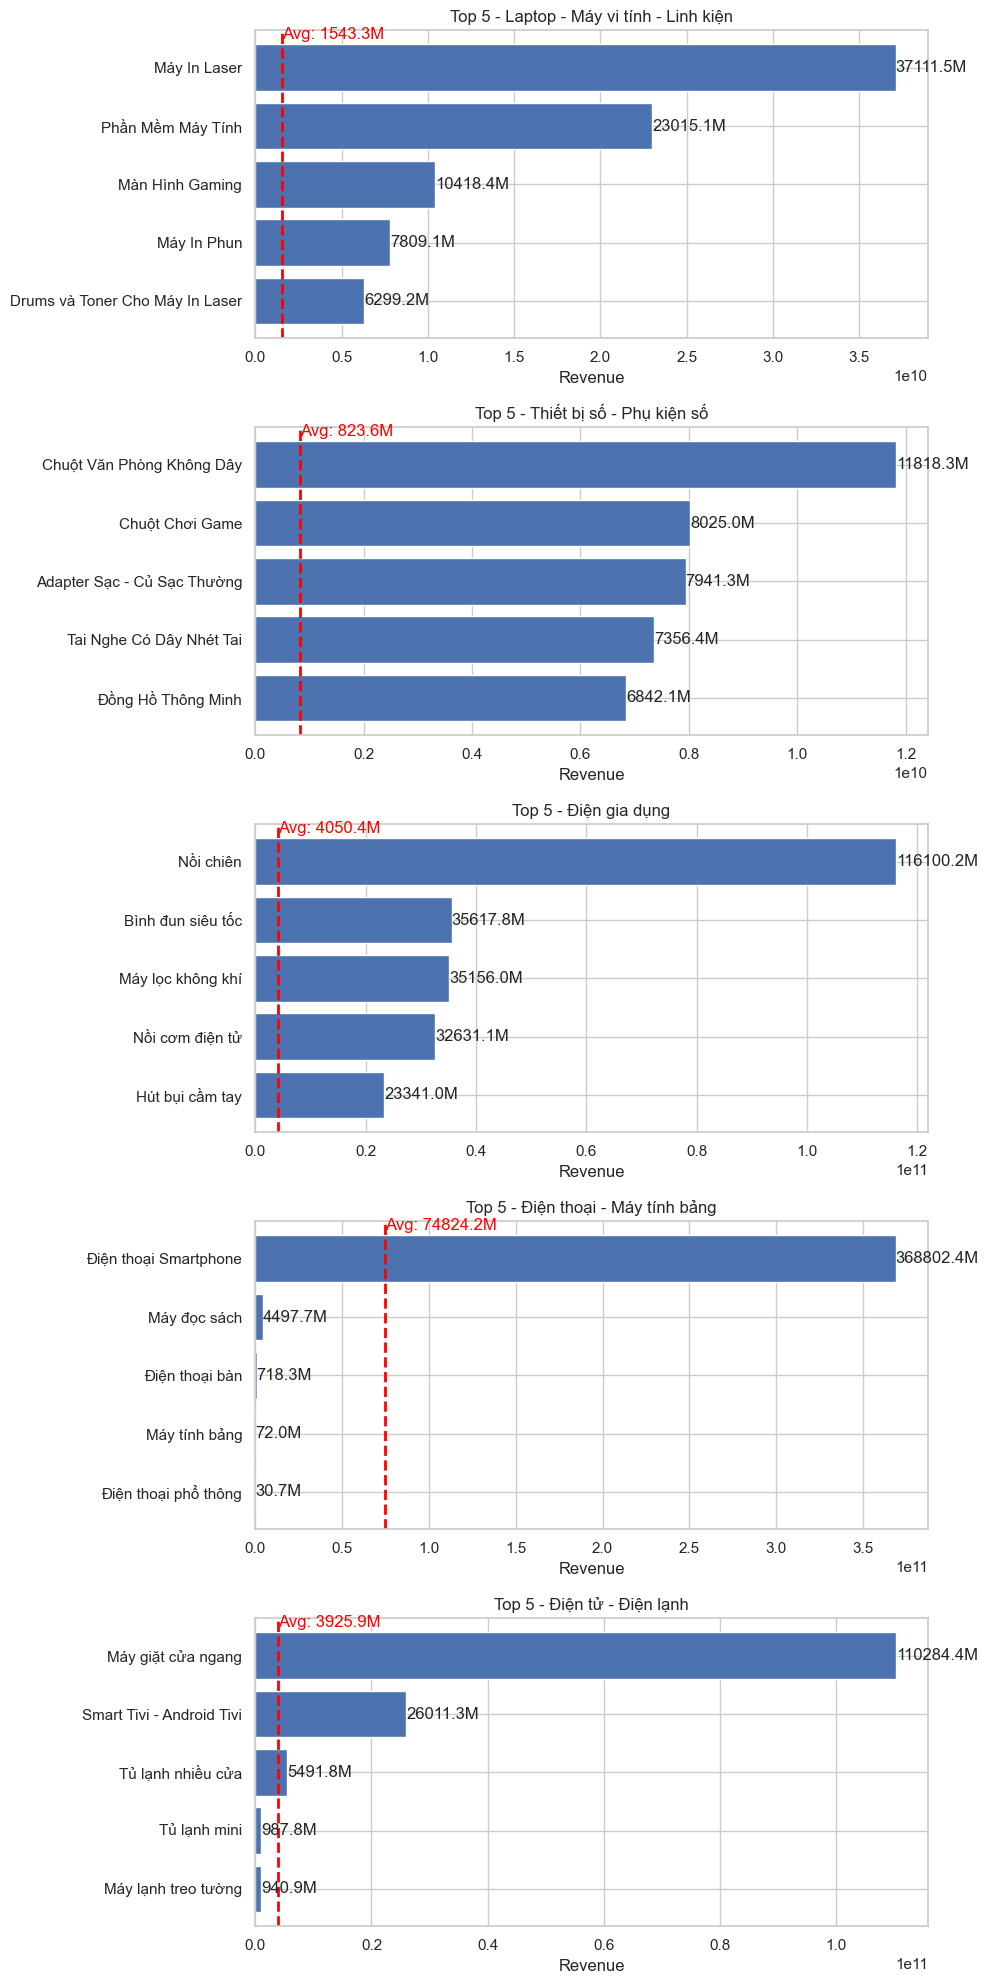

In [52]:
roots = top5_each_root["root_category_name"].unique()
n = len(roots)

fig, axes = plt.subplots(n, 1, figsize=(10, 4*n), squeeze=False)
axes = axes.flatten()

for i, root in enumerate(roots):
    data = top5_each_root[top5_each_root["root_category_name"] == root]
    
    axes[i].barh(data["category_name"], data["revenue"])
    axes[i].invert_yaxis()
    
    for j, v in enumerate(data["revenue"]):
        axes[i].text(v, j, f"{v/1e6:.1f}M", va='center')

    axes[i].axvline(x=avg_each_root[avg_each_root["root_category_name"] == root]["avg_revenue"].values[0],
                        color='red', linestyle='--', linewidth=2)
    axes[i].text(avg_each_root[avg_each_root["root_category_name"] == root]["avg_revenue"].values[0], -0.5,
                    f"Avg: {avg_each_root[avg_each_root['root_category_name'] == root]['avg_revenue'].values[0]/1e6:.1f}M", color='red')

    axes[i].set_title(f"Top 5 - {root}")
    axes[i].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

Observation:
- Tổng quan:
    - Tương tự như kết quả Top 5 doanh thu trên toàn bộ dataset, khi phân tích theo từng danh mục gốc, có thể thấy sự chênh lệch doanh thu giữa các category con vẫn rất rõ rệt.
    - Trong hầu hết các danh mục, giá trị trung bình nằm thấp hơn đáng kể so với nhóm Top 5, cho thấy phân phối doanh thu có xu hướng lệch phải. Điều này hàm ý rằng một số ít category đóng góp phần lớn doanh thu.
    - Đặc biệt, ở danh mục Điện thoại - Máy tính bảng, giá trị trung bình cao hơn so với các danh mục khác. Tuy nhiên, hiện tượng này nhiều khả năng bị chi phối bởi một category vượt trội (ví dụ: Điện thoại Smartphone), dẫn đến việc trung bình bị kéo lên.
    - Hiện tượng tương tự cũng xuất hiện ở Điện tử - Điện lạnh, khi Top 1 category có doanh thu vượt trội so với phần còn lại.
- Chi tiết từng lĩnh vực:
    - Laptop - Máy vi tính - Linh kiện: Đây là danh mục có mức độ phân bổ doanh thu tương đối đồng đều hơn so với các nhóm khác, thể hiện qua sự chênh lệch không quá lớn giữa các category trong Top 5.
    - Thiết bị số - Phụ kiện số: Là danh mục có mức độ đồng đều cao nhất, tuy nhiên tổng doanh thu thấp hơn đáng kể so với các danh mục khác, cho thấy đây có thể là thị trường phân mảnh và cạnh tranh cao.
    - Điện gia dụng: Doanh thu trong Top 5 có sự chênh lệch nhất định, tuy nhiên nhiều category vẫn duy trì mức doanh thu cao và xuất hiện trong Top 5 toàn dataset, cho thấy đây là một ngành hàng có quy mô lớn và đóng góp đáng kể.
    - Điện thoại - Máy tính bảng: Category Smartphone vượt trội hoàn toàn so với các category còn lại, phản ánh mức độ tập trung doanh thu rất cao. Các category khác có xu hướng phục vụ các nhu cầu ngách và đóng góp doanh thu hạn chế hơn.
    - Điện tử - Điện lạnh: Category Máy giặt cửa ngang có doanh thu vượt trội, trong khi các category còn lại vẫn duy trì mức doanh thu tương đối tốt. Điều này cho thấy thị trường vừa có sản phẩm chủ lực, vừa có sự đa dạng nhất định.
    

Insight:
- Phân tích cho thấy trong hầu hết các danh mục gốc, doanh thu có xu hướng tập trung vào một số ít category, với Top 1 thường chiếm tỷ trọng lớn so với phần còn lại. Điều này phản ánh sự tồn tại của các *mặt hành chủ lực* trong từng ngành hàng.
- Tuy nhiên, mức độ tập trung này không đồng đều giữa các danh mục. Một số ngành có cấu trúc cân bằng hơn (phân phối đều), trong khi các ngành khác phụ thuộc mạnh vào một category duy nhất.
- Cần lưu ý rằng doanh thu chỉ phản ánh một phần hiệu quả kinh doanh. Việc đánh giá tiềm năng thực sự của category cần xem xét thêm các yếu tố khác như chi phí, lợi nhuận hoặc tốc độ tăng trưởng. Đây những yếu tố không có trong dataset hiện tại.

In [53]:
df_group_rank = (
    df_q1_product
    .groupby(["root_category_name", "category_name"])["sold_count"]
    .sum()
    .reset_index()
)

df_group_rank["rank"] = df_group_rank.groupby("root_category_name")["sold_count"] \
                          .rank(method="first", ascending=False)

top5_each_root = df_group_rank[df_group_rank["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

df_group_rank["pct_in_root"] = df_group_rank["sold_count"] / df_group_rank.groupby("root_category_name")["sold_count"].transform("sum")

In [54]:
top5_all_rank = (
    df_group_rank
    .groupby("category_name")["sold_count"]
    .sum()
    .reset_index()
    .sort_values(by="sold_count", ascending=False)
    .head(5)
)

avg_all_rank = df_group_rank.groupby("category_name")["sold_count"].sum().mean()

# =========================
# TOP 5 MỖI ROOT
# =========================
top5_each_root_rank = df_group_rank[df_group_rank["rank"] <= 5] \
                    .sort_values(["root_category_name", "rank"])

# average theo từng root
avg_each_root_rank = (
    df_group_rank
    .groupby("root_category_name")["sold_count"]
    .mean()
    .reset_index(name="avg_sold_count")
)


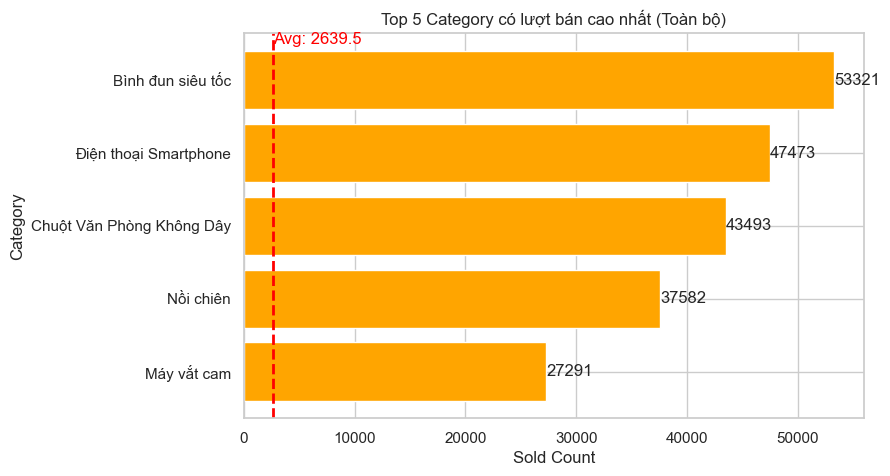

In [68]:
plt.figure(figsize=(8,5))

plt.barh(top5_all_rank["category_name"], top5_all_rank["sold_count"], color='orange')
plt.gca().invert_yaxis()

for i, v in enumerate(top5_all_rank["sold_count"]):
    plt.text(v, i, f"{v}", va='center')

# vẽ đường average
plt.axvline(x=avg_all_rank, color='red', linestyle='--', linewidth=2)

# label cho avg
plt.text(avg_all_rank, -0.5, f"Avg: {avg_all_rank:0.1f}", color='red')

plt.title("Top 5 Category có lượt bán cao nhất (Toàn bộ)")
plt.xlabel("Sold Count")
plt.ylabel("Category")

plt.show()

Observation:
- So với bảng xếp hạng theo doanh thu, kết quả dựa trên số lượng bán ra (sold_count) cho thấy sự thay đổi đáng kể về thứ hạng các sản phẩm.
- Cụ thể, các sản phẩm có mức giá thấp như bình đun siêu tốc vươn lên vị trí dẫn đầu về số lượng bán ra, mặc dù không phải là sản phẩm có doanh thu cao nhất. Điều này phản ánh sự khác biệt giữa hai chỉ số: doanh thu và nhu cầu thị trường.
- Điện thoại Smartphone vẫn giữ vị trí Top 2 về số lượng bán, dù thuộc phân khúc giá cao hơn đáng kể so với các sản phẩm còn lại. Điều này cho thấy mức độ phổ biến và nhu cầu ổn định của category này.
- Ngoài ra, sự xuất hiện của các sản phẩm như chuột văn phòng không dây và máy vắt cam trong Top 5 cho thấy vai trò của các sản phẩm giá thấp và tiêu dùng thường xuyên trong việc thúc đẩy số lượng giao dịch.
- Đáng chú ý, có đến 3/5 sản phẩm bán chạy nhất thuộc nhóm Điện gia dụng, cho thấy đây là nhóm có nhu cầu tiêu dùng cao và phổ biến trong đời sống hàng ngày.

Insight:
- Kết quả cho thấy sự khác biệt rõ ràng giữa hai góc nhìn: doanh thu và số lượng bán ra. Trong khi doanh thu thường bị chi phối bởi các sản phẩm giá cao, thì số lượng bán ra phản ánh trực tiếp nhu cầu thị trường.
- Các sản phẩm giá thấp có xu hướng xuất hiện nhiều hơn trong Top bán chạy do:
    - chi phí thấp -> giảm rào cản mua hàng trực tuyến(không sợ lừa đảo, rủi ro vận chuyển,...)
    - tần suất sử dụng cao -> nhu cầu lặp lại (Các sản phẩm này thường có tác dụng ngay tức thì, độ bền không cao hoặc một số sản phẩm được thiết kế để dùng trong giai đoạn ngắn)
- Tuy nhiên, sự xuất hiện của Điện thoại Smartphone trong Top 2 cho thấy đây là một category vừa có giá trị cao vừa có nhu cầu lớn. Đây là một insight khá mới với em trong thương mại điện tử.

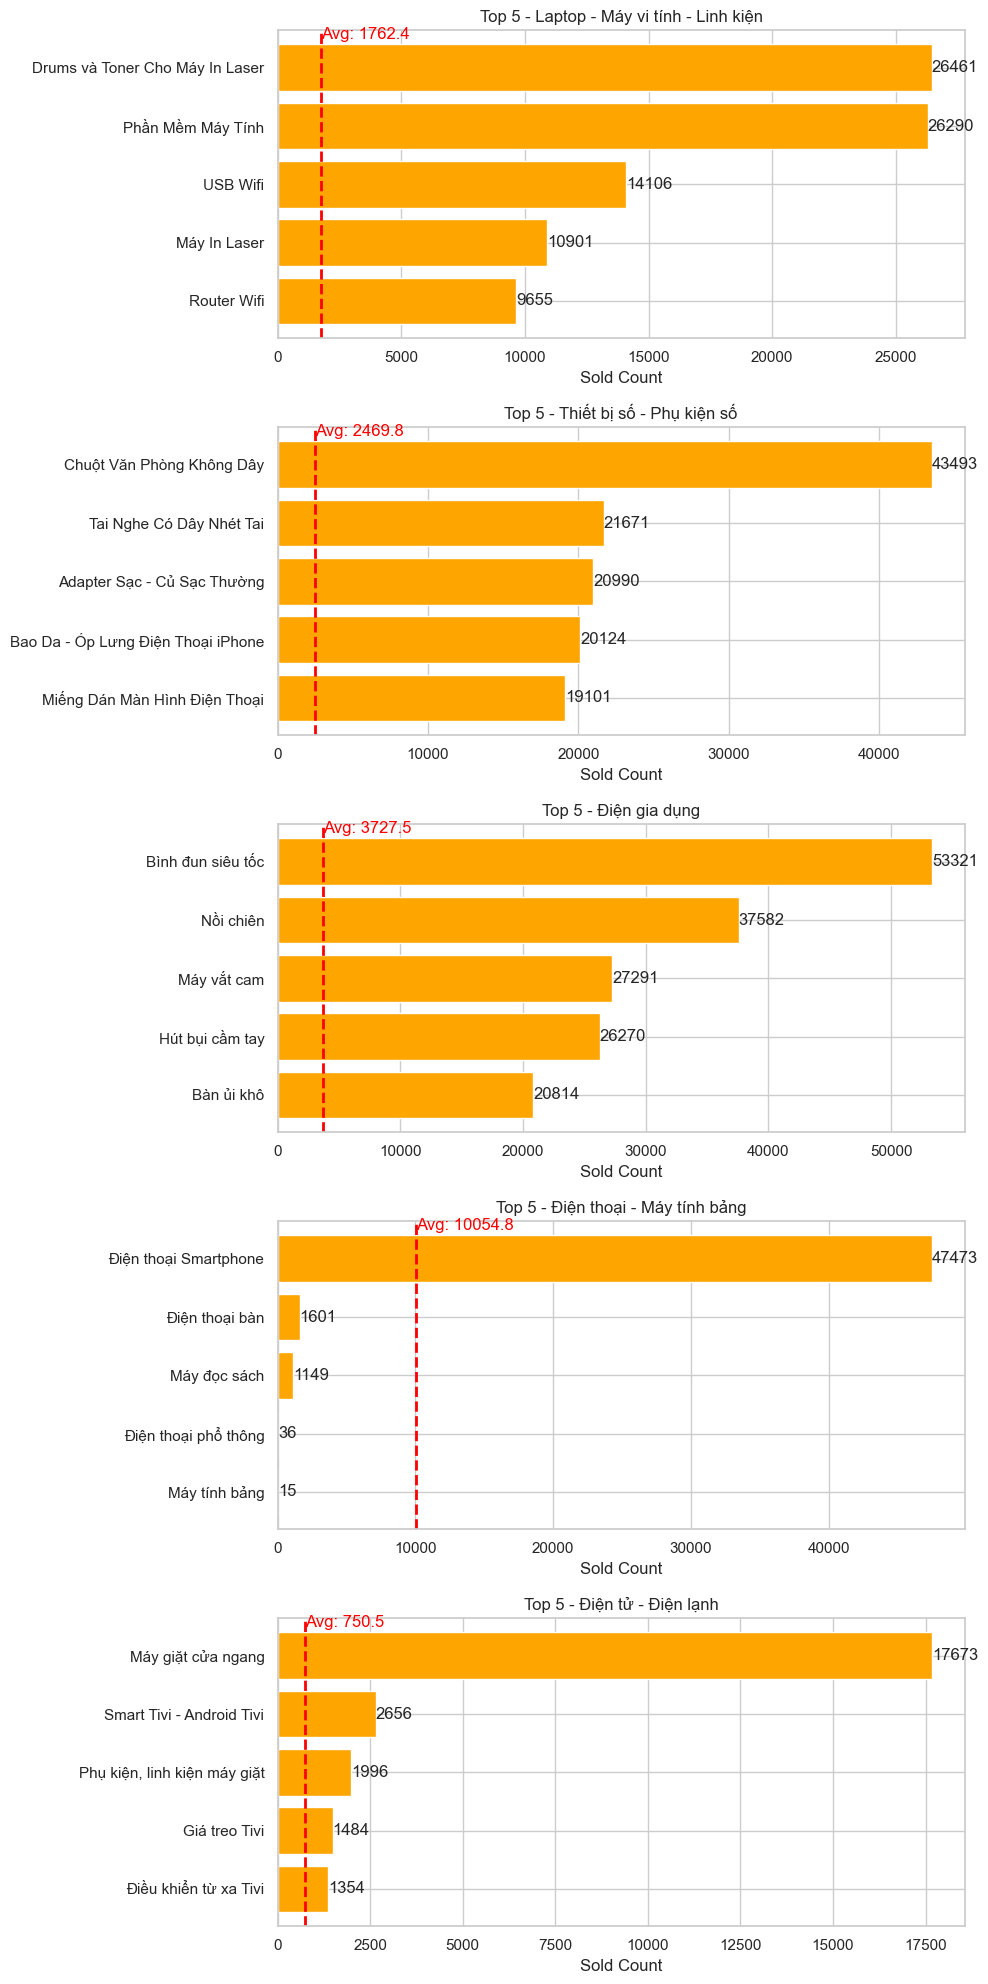

In [69]:
roots = top5_each_root_rank["root_category_name"].unique()
n = len(roots)

fig, axes = plt.subplots(n, 1, figsize=(10, 4*n), squeeze=False)
axes = axes.flatten()
    
for i, root in enumerate(roots):
    data = top5_each_root_rank[top5_each_root_rank["root_category_name"] == root]
    
    axes[i].barh(data["category_name"], data["sold_count"], color='orange')
    axes[i].invert_yaxis()
    
    for j, v in enumerate(data["sold_count"]):
        axes[i].text(v, j, f"{v}", va='center')

    axes[i].axvline(x=avg_each_root_rank[avg_each_root_rank["root_category_name"] == root]["avg_sold_count"].values[0],
                        color='red', linestyle='--', linewidth=2)
    axes[i].text(avg_each_root_rank[avg_each_root_rank["root_category_name"] == root]["avg_sold_count"].values[0], -0.5,
                    f"Avg: {avg_each_root_rank[avg_each_root_rank['root_category_name'] == root]['avg_sold_count'].values[0]:0.1f}", color='red')

    axes[i].set_title(f"Top 5 - {root}")
    axes[i].set_xlabel("Sold Count")

plt.tight_layout()
plt.show()

Observation:
- Tổng quan:
    - Phân phối theo số lượng bán ra nhìn chung tương đồng với kết quả theo doanh thu, tuy nhiên có xu hướng đồng đều hơn ở một số danh mục.
    - Đáng chú ý, mặc dù có sự chênh lệch lớn về giá, Điện thoại Smartphone vẫn duy trì mức độ áp đảo về số lượng bán trong cùng danh mục gốc, cho thấy nhu cầu mạnh và ổn định.
    - XNgoài ra, danh sách Top 5 xuất hiện nhiều hơn các sản phẩm thuộc phân khúc giá thấp như phụ kiện hoặc các mặt hàng tiêu dùng phổ biến, phản ánh sự dịch chuyển từ high-value sang high-volume products.
- Chi tiết từng danh mục:
    - Laptop - Máy vi tính - Linh kiện: Hai sản phẩm bổ trợ (phụ kiện) chiếm Top 1 và Top 2 với số lượng bán gần như tương đương (26,461 và 26,290), cho thấy nhu cầu ổn định và ít chênh lệch. Ngoài ra, xuất hiện thêm các sản phẩm liên quan đến Wifi so với bảng xếp hạng theo doanh thu.
    - Thiết bị số - Phụ kiện số: Tương tự kết quả theo doanh thu, nhưng ghi nhận thêm sự xuất hiện của các sản phẩm giá rẻ như bao da/ốp lưng và miếng dán màn hình — những mặt hàng có tần suất mua cao.
    - Điện gia dụng: Có sự thay đổi thứ hạng giữa các sản phẩm chủ lực như nồi chiên không dầu và bình đun siêu tốc. Đồng thời, xuất hiện thêm các sản phẩm giá thấp như máy vắt cam và bàn ủi khô, góp phần làm tăng số lượng bán.
    - Điện thoại - Máy tính bảng: Điện thoại Smartphone vẫn duy trì khoảng cách rất lớn so với các category còn lại. Các sản phẩm trong Top 5 phần lớn giữ nguyên so với bảng doanh thu, nhưng có sự thay đổi về thứ hạng.
    - Điện tử - điện lạnh: Các sản phẩm giá trị cao như tủ lạnh, máy lạnh (xuất hiện trong Top doanh thu) không còn nằm trong Top bán chạy, thay vào đó là các nhóm phụ kiện như linh kiện máy giặt, giá treo TV và điều khiển TV — những sản phẩm có giá thấp hơn nhưng nhu cầu cao hơn.
Insight:
- Phân tích cho thấy sự khác biệt rõ ràng giữa cấu trúc doanh thu và cấu trúc nhu cầu thị trường. Trong khi doanh thu tập trung vào các sản phẩm giá trị cao, thì số lượng bán ra lại nghiêng về các sản phẩm giá thấp và tiêu dùng thường xuyên.
- Sự xuất hiện ngày càng nhiều của các sản phẩm giá rẻ trong Top bán chạy cho thấy hành vi người tiêu dùng trên nền tảng thương mại điện tử ưu tiên các sản phẩm:
    - có giá thấp → giảm rào cản mua hàng
    - có tần suất sử dụng cao → nhu cầu lặp lại
    - ít rủi ro khi mua online
- Tuy nhiên, Điện thoại Smartphone là một trường hợp đặc biệt khi vừa duy trì được mức giá cao, vừa đạt số lượng bán lớn. Điều này cho thấy đây là category có khả năng cân bằng giữa high value và high demand, đóng vai trò quan trọng trong toàn bộ hệ sinh thái sản phẩm.
- Ngoài ra, sự thay thế của các sản phẩm giá trị cao bằng phụ kiện trong một số danh mục (như Điện tử - Điện lạnh) cho thấy doanh thu cao không đồng nghĩa với tần suất giao dịch cao. Các sản phẩm phụ trợ, dù giá trị thấp, lại đóng vai trò quan trọng trong việc duy trì lưu lượng giao dịch và mức độ hoạt động của nền tảng.

### Analysis and Conclusion - Question 1

#### Key Observations:

1. 
2. 
3. 
#### Conclusion:


# Question 2

## 4. Question 2: 

In [57]:
df_q2_product = df_q1_product.copy()
df_q2_category = df_q1_category.copy()
df_q2_store = df_store.copy()
df_q2_review = df_review.copy()

In [58]:
df_review_agg = (
    df_q2_review
    .groupby("product_id")
    .agg({
        "rating": ["mean", "count"],
        "like_count": "mean"
    })
)

df_review_agg.columns = ["review_rating_avg", "review_count", "review_like_avg"]
df_review_agg = df_review_agg.reset_index()

In [59]:
df = df_q2_product.merge(
    df_review_agg, on="product_id", how="left", suffixes=("", "_drop")
)
df = df.merge(df_q2_store, on="store_id", how="left", suffixes=("", "_drop2"))
df = df[[c for c in df.columns if not c.endswith(("_drop", "_drop2"))]]

In [60]:
df.fillna({
    "review_rating_avg": 0,
    "review_count": 0,
    "review_like_avg": 0,
    "store_rating": 0,
    "follower_count": 0
}, inplace=True)

In [ ]:
df_cat_product = (
    df
    .groupby(["category_name", "product_id", "product_name"])
    .agg({
        "revenue": "sum",
        "sold_count": "sum"
    })
    .reset_index()
)

In [ ]:
results = []

for cat, group in df_cat_product.groupby("category_name"):
    revenues = group["revenue"]
    
    total = revenues.sum()
    mean = revenues.mean()
    std = revenues.std()
    
    cv = std / mean if mean != 0 else 0
    
    sorted_rev = revenues.sort_values(ascending=False)
    
    top1_share = sorted_rev.iloc[0] / total
    top3_share = sorted_rev.head(3).sum() / total
    
    results.append({
        "category": cat,
        "num_products": len(group),
        "cv_revenue": cv,
        "top1_share": top1_share,
        "top3_share": top3_share
    })

df_analysis = pd.DataFrame(results)

In [ ]:
df_analysis["dominant_flag"] = df_analysis["top1_share"] > 0.4

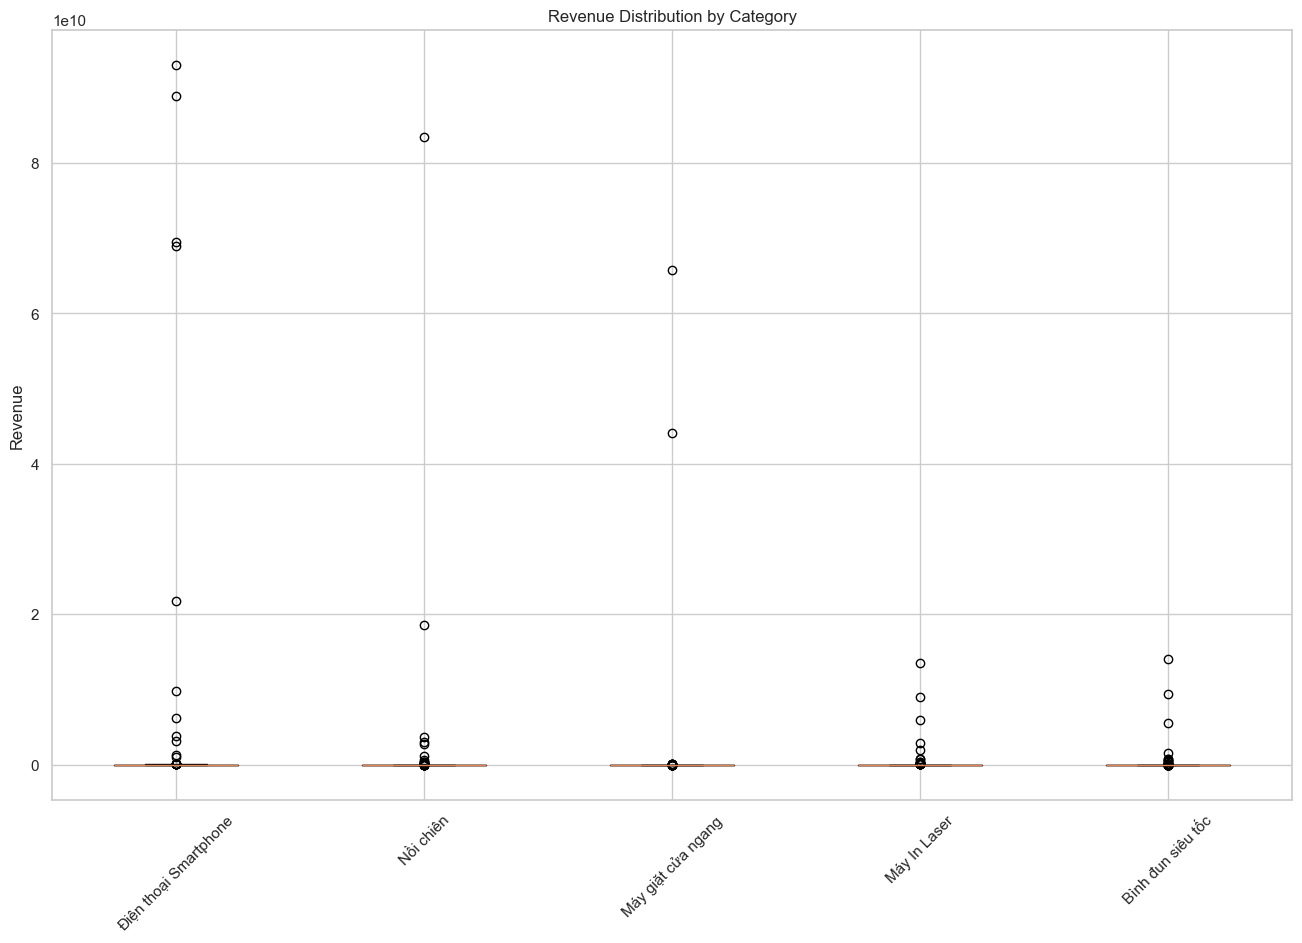

In [ ]:
# chọn top N category để plot cho dễ nhìn
top_categories = (
    df_cat_product.groupby("category_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

data = [
    df_cat_product[df_cat_product["category_name"] == cat]["revenue"]
    for cat in top_categories
]

plt.figure()
plt.boxplot(data, labels=top_categories)
plt.title("Revenue Distribution by Category")
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.show()

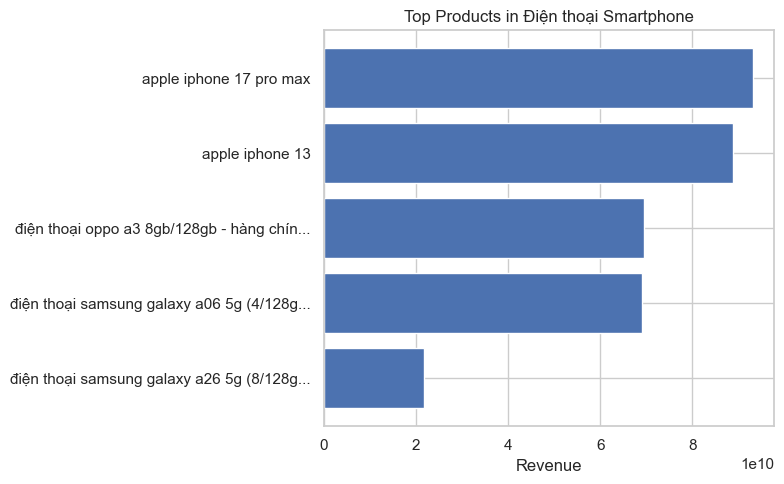

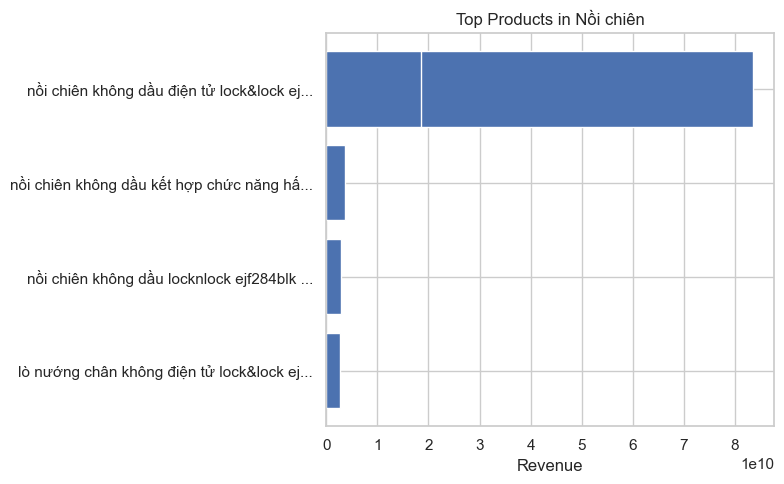

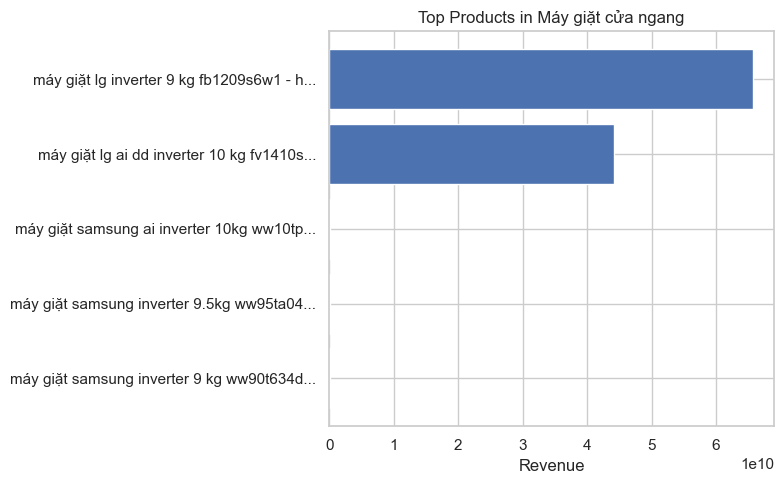

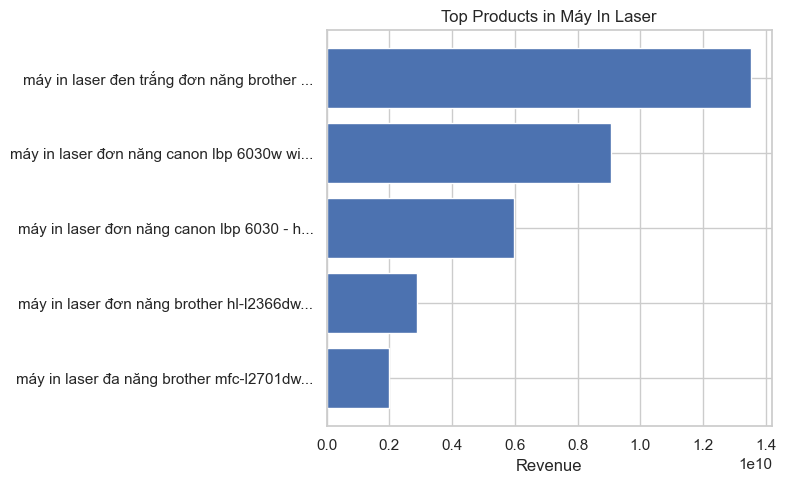

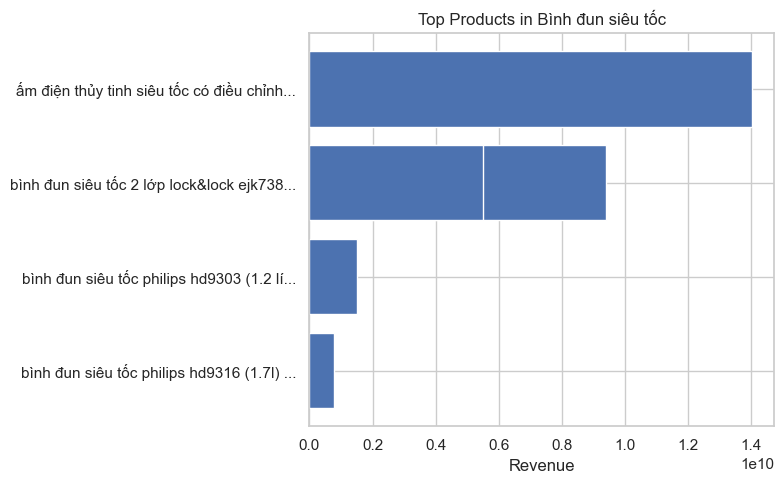

In [ ]:
def truncate_text(text, max_len=40):
    return text if len(text) <= max_len else text[:max_len] + "..."

for cat in top_categories:
    df_sub = df_cat_product[df_cat_product["category_name"] == cat]
    top_products = df_sub.sort_values(by="revenue", ascending=False).head(5).copy()
    
    # rút gọn tên
    top_products["short_name"] = top_products["product_name"].apply(truncate_text)

    plt.figure(figsize=(8, 5))
    plt.barh(top_products["short_name"], top_products["revenue"])
    plt.gca().invert_yaxis()  # top cao nhất nằm trên
    
    plt.title(f"Top Products in {cat}")
    plt.xlabel("Revenue")
    plt.ylabel("")
    
    plt.tight_layout()
    plt.show()

### Analysis and Conclusion - Question 2

#### Key Observations:

1. 
2. 
3. 

#### Conclusion:


---
## OVERALL CONCLUSION
